In [1]:
# ==========================================================
# Multiclass Crime Detection using MobileNetV2
# Cell 1 - Mount Google Drive
# ==========================================================

from google.colab import drive
import os

drive.mount('/content/drive', force_remount=True)

print("Drive mounted successfully.")

DATASET_PATH = "/content/drive/MyDrive/OUR_DATASET/Combined_Dataset_Augmented"

if os.path.exists(DATASET_PATH):
    print("\nDataset found.")
    print(DATASET_PATH)
else:
    print("\nDataset NOT found.")

Mounted at /content/drive
Drive mounted successfully.

Dataset found.
/content/drive/MyDrive/OUR_DATASET/Combined_Dataset_Augmented


In [2]:
# ==========================================================
# Multiclass Crime Detection using MobileNetV2
# Cell 2 - Import Libraries
# ==========================================================

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers
from tensorflow.keras import models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# ----------------------------------------------------------
# Set Random Seed
# ----------------------------------------------------------

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow Version :", tf.__version__)
print("Num GPUs Available :", len(tf.config.list_physical_devices('GPU')))

TensorFlow Version : 2.20.0
Num GPUs Available : 0


In [3]:
# ==========================================================
# Multiclass Crime Detection using MobileNetV2
# Cell 3 - Configuration
# ==========================================================

# -----------------------------
# Dataset Paths
# -----------------------------

MODEL_NAME = "MobileNetV2_Aug"

DATASET_PATH = "/content/drive/MyDrive/OUR_DATASET/Combined_Dataset_Augmented"

TRAIN_DIR = os.path.join(DATASET_PATH, "Train")
VAL_DIR = os.path.join(DATASET_PATH, "Validation")
TEST_DIR = os.path.join(DATASET_PATH, "Test")

# -----------------------------
# Image Parameters
# -----------------------------

IMAGE_SIZE = (224, 224)

BATCH_SIZE = 32

# -----------------------------
# Training Parameters
# -----------------------------

EPOCHS = 30

LEARNING_RATE = 0.0001

# -----------------------------
# Model Parameters
# -----------------------------

NUM_CLASSES = 6

CLASS_NAMES = sorted(os.listdir(TRAIN_DIR))

print("Classes Found:")
print(CLASS_NAMES)

# -----------------------------
# Save Paths
# -----------------------------

BASE_PATH = "/content/drive/MyDrive/OUR_DATASET"

REPORT_PATH = os.path.join(BASE_PATH, MODEL_NAME)

os.makedirs(REPORT_PATH, exist_ok=True)

MODEL_PATH = os.path.join(
    REPORT_PATH,
    "crime_detector_mobilenetv2_Aug.keras"
)


print("\nConfiguration Loaded Successfully")

Classes Found:
['Abuse', 'Burglary', 'Fighting', 'Normal', 'RoadAccident', 'Snatching']

Configuration Loaded Successfully


In [4]:
# ==========================================================
# Multiclass Crime Detection using MobileNetV2
# Cell 4 - Load Dataset
# ==========================================================

train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="categorical",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    labels="inferred",
    label_mode="categorical",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels="inferred",
    label_mode="categorical",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("\nDataset Loaded Successfully")

print("\nTraining batches   :", len(train_dataset))
print("Validation batches :", len(validation_dataset))
print("Test batches       :", len(test_dataset))

Found 13708 files belonging to 6 classes.
Found 2487 files belonging to 6 classes.
Found 2508 files belonging to 6 classes.

Dataset Loaded Successfully

Training batches   : 429
Validation batches : 78
Test batches       : 79


In [5]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

AUTOTUNE = tf.data.AUTOTUNE

def preprocess(images, labels):
    images = preprocess_input(images)
    return images, labels

train_dataset = train_dataset.map(
    preprocess,
    num_parallel_calls=AUTOTUNE
)

validation_dataset = validation_dataset.map(
    preprocess,
    num_parallel_calls=AUTOTUNE
)

test_dataset = test_dataset.map(
    preprocess,
    num_parallel_calls=AUTOTUNE
)

In [6]:
# ==========================================================
# Multiclass Crime Detection using MobileNetV2
# Cell 5 - Optimize Dataset Performance
# ==========================================================

AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)

validation_dataset = validation_dataset.prefetch(buffer_size=AUTOTUNE)

test_dataset = test_dataset.prefetch(buffer_size=AUTOTUNE)

print("Dataset optimization completed.")

Dataset optimization completed.


Found 13708 files belonging to 6 classes.


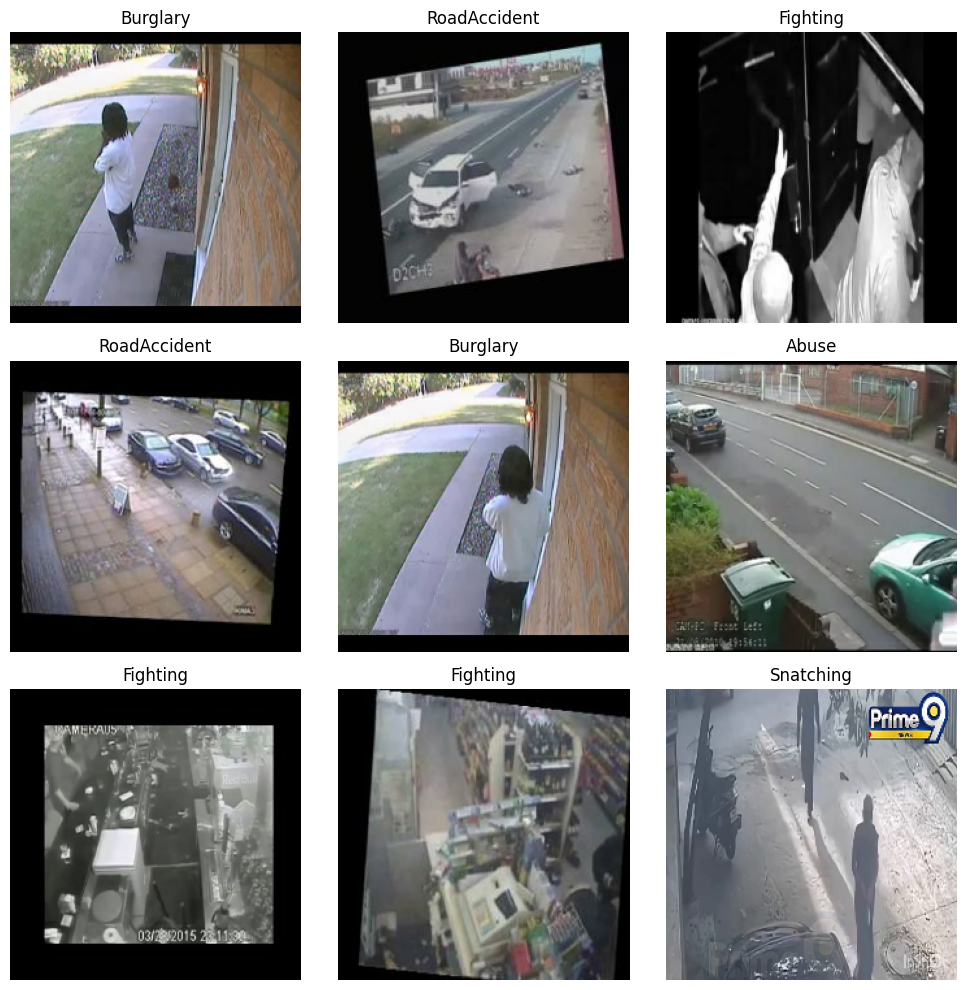

In [7]:
# ==========================================================
# Multiclass Crime Detection using MobileNetV2
# Cell 6 - Visualize Sample Images
# ==========================================================

sample_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="categorical",
    image_size=IMAGE_SIZE,
    batch_size=9,
    shuffle=True,
    seed=SEED
)

images, labels = next(iter(sample_dataset))

plt.figure(figsize=(10,10))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(images[i].numpy().astype("uint8"))

    plt.title(CLASS_NAMES[np.argmax(labels[i].numpy())])

    plt.axis("off")

plt.tight_layout()
plt.show()

In [8]:
# ==========================================================
# Multiclass Crime Detection using MobileNetV2
# Cell 7 - Build MobileNetV2 Model
# ==========================================================



# -----------------------------
# MobileNetV2 Base Model
# -----------------------------

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze the pretrained layers
base_model.trainable = False

# -----------------------------
# Build Model
# -----------------------------

inputs = tf.keras.Input(shape=(224, 224, 3))

#x = data_augmentation(inputs)

#x = preprocess_input(inputs)

x = base_model(inputs, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.30)(x)

outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)

model = tf.keras.Model(inputs, outputs, name="CrimeDetection_MobileNetV2_Aug")

print("Model Created Successfully")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Model Created Successfully


In [9]:
# ==========================================================
# Multiclass Crime Detection using MobileNetV2
# Cell 8 - Compile Model
# ==========================================================

optimizer = tf.keras.optimizers.Adam(
    learning_rate=LEARNING_RATE
)

model.compile(
    optimizer=optimizer,
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.\n")

model.summary()

Model compiled successfully.



Model: "CrimeDetection_MobileNetV2_Aug"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │         7,686 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,265,670 (8.64 MB)

 Trainable params: 7,686 (30.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [10]:
# ==========================================================
# Multiclass Crime Detection using MobileNetV2
# Cell 9 - Training Callbacks
# ==========================================================

# Save the best model
checkpoint = ModelCheckpoint(
    filepath=MODEL_PATH,
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

# Stop training if validation loss doesn't improve
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Reduce learning rate when validation loss plateaus
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

callbacks = [
    checkpoint,
    early_stopping,
    reduce_lr
]

print("Callbacks created successfully.")

Callbacks created successfully.


In [11]:
# ==========================================================
# Multiclass Crime Detection using MobileNetV2
# Cell 10 - Compute Class Weights
# ==========================================================
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Number of training images in each class.
# These values are obtained from the dataset builder summary
# and are used to compute balanced class weights.
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

import numpy as np

counts = np.array([2000, 2000, 2000, 2000, 2000, 3708], dtype=np.float32)

total = counts.sum()
num_classes = len(counts)

weights = total / (num_classes * counts)

class_weights = {
    i: float(weights[i])
    for i in range(num_classes)
}

print(class_weights)

{0: 1.1423333883285522, 1: 1.1423333883285522, 2: 1.1423333883285522, 3: 1.1423333883285522, 4: 1.1423333883285522, 5: 0.6161452531814575}


In [ ]:
# ==========================================================
# Multiclass Crime Detection using MobileNetV2
# Cell 11 - Train Model
# ==========================================================

history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS,
    callbacks=callbacks,
    class_weight=class_weights,
    verbose=1
)

print("\nTraining Completed Successfully.")

Epoch 1/30
  2/429 ━━━━━━━━━━━━━━━━━━━━ 1:15:00 11s/step - accuracy: 0.1719 - loss: 2.4515

In [ ]:
# Accuracy plot
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid(True)

plt.savefig(
    os.path.join(REPORT_PATH, "accuracy_plot.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [ ]:
# Loss plot
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)

plt.savefig(
    os.path.join(REPORT_PATH, "loss_plot.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [ ]:
#Validation Performance

val_loss, val_accuracy = model.evaluate(
    validation_dataset,
    verbose=1
)

print(f"Validation Loss     : {val_loss:.4f}")
print(f"Validation Accuracy : {val_accuracy:.4f}")



In [ ]:
#Test Evaluation
test_loss, test_accuracy = model.evaluate(
    test_dataset,
    verbose=1
)

print("Test Accuracy :", test_accuracy)
print("Test Loss :", test_loss)


In [ ]:
#Summary of Results
print("="*40)
print("FINAL MODEL PERFORMANCE")
print("="*40)

print(f"Training Accuracy   : {history.history['accuracy'][-1]:.4f}")
print(f"Validation Accuracy : {val_accuracy:.4f}")
print(f"Test Accuracy       : {test_accuracy:.4f}")

print(f"\nTraining Loss       : {history.history['loss'][-1]:.4f}")
print(f"Validation Loss     : {val_loss:.4f}")
print(f"Test Loss           : {test_loss:.4f}")


In [ ]:
import numpy as np

# Store true labels and predictions
y_true = []
y_pred = []

# Predict on the test dataset
for images, labels in test_dataset:
    predictions = model.predict(images, verbose=0)

    predicted_classes = np.argmax(predictions, axis=1)

    y_pred.extend(predicted_classes)
    y_true.extend(labels.numpy())

# Convert to numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Number of test samples:", len(y_true))
print("Predictions generated successfully.")

In [ ]:
y_true = np.argmax(y_true, axis=1)

In [ ]:
for i in range(10):
    print(
        f"Actual: {CLASS_NAMES[y_true[i]]} | "
        f"Predicted: {CLASS_NAMES[y_pred[i]]}"
    )

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Convert to DataFrame for readability
cm_df = pd.DataFrame(
    cm,
    index=CLASS_NAMES,
    columns=CLASS_NAMES
)

plt.figure(figsize=(14,12))

sns.heatmap(
    cm_df,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix")

plt.tight_layout()

plt.savefig(
    os.path.join(REPORT_PATH, "confusion_matrix.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
from sklearn.metrics import classification_report

report = classification_report(
    y_true,
    y_pred,
    target_names=CLASS_NAMES,
    digits=4
)

print(report)

In [ ]:
report_dict = classification_report(
    y_true,
    y_pred,
    target_names=CLASS_NAMES,
    output_dict=True
)

report_df = pd.DataFrame(report_dict).transpose()



report_df.head()

In [ ]:
history_df.to_csv(
    os.path.join(REPORT_PATH, "training_history.csv"),
    index=False
)

report_df.to_csv(
    os.path.join(REPORT_PATH, "classification_report.csv"),
    index=True
)

cm_df.to_csv(
    os.path.join(REPORT_PATH, "confusion_matrix.csv"),
    index=True
)

model.save(MODEL_PATH)

print("All results saved successfully.")